# COde

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
from typing import Union
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt
def _butter_filter(ts, fs, hp_cutoff=None, lp_cutoff=None, order=4):
    """High/low/band pass filter, same as before."""
    nyq = 0.5 * fs
    if hp_cutoff is None and lp_cutoff is None:
        return ts

    if hp_cutoff and lp_cutoff:
        btype = 'band'
        freqs = [hp_cutoff/nyq, lp_cutoff/nyq]
    elif hp_cutoff:
        btype = 'high'; freqs = hp_cutoff/nyq
    else:
        btype = 'low';  freqs = lp_cutoff/nyq

    b, a = butter(order, freqs, btype=btype)
    return filtfilt(b, a, ts)

# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(data: Union[xr.DataArray, np.ndarray],
                      fs: float,
                      poly_order: int = 1,
                      hp_cutoff: float = None,
                      lp_cutoff: float = None,
                      filter_order: int = 4) -> np.ndarray:
    """
    Globally filter and detrend the data, then return as numpy array.
    Handles both xarray DataArrays and 1D numpy arrays.
    """
    # Handle 1D numpy array input
    if isinstance(data, np.ndarray):
        if data.ndim != 1:
            raise ValueError("Numpy array input must be 1D")
        
        ts = data.astype(float)
        N = len(ts)
        tidx = np.arange(N)
        
        # Filter
        tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
        
        # Detrend
        coeffs = np.polyfit(tidx, tsf, poly_order)
        return tsf - np.polyval(coeffs, tidx)
    
    # Handle xarray DataArray (original code)
    axes = data.coords['axis'].values
    chans = data.coords['channel'].values
    full = data.copy(deep=True).astype(float)
    N = full.sizes['time']
    tidx = np.arange(N)
    
    for ax in axes:
        for ch in chans:
            ts = full.sel(axis=ax, channel=ch).values
            tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
            coeffs = np.polyfit(tidx, tsf, poly_order)
            full.loc[dict(axis=ax, channel=ch)] = tsf - np.polyval(coeffs, tidx)
    
    return full.values

import numpy as np
from scipy.signal import butter, filtfilt

def approximate_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Approximate Entropy (ApEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    
    def phi(mv):
        X = np.array([U[i:i+mv] for i in range(N-mv+1)])
        C = []
        for xi in X:
            # Count patterns within tolerance r
            matches = np.sum(np.max(np.abs(X - xi), axis=1) <= r)
            C.append(matches / (N - mv + 1))
        # Avoid log(0) by adding small epsilon
        C = np.array(C)
        C[C == 0] = np.finfo(float).eps
        return np.mean(np.log(C))
    
    return phi(m) - phi(m+1)

def sample_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Sample Entropy (SampEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    
    # Templates of length m
    X = np.array([U[i:i+m] for i in range(N-m+1)])
    # Templates of length m+1
    X1 = np.array([U[i:i+m+1] for i in range(N-m)])
    
    def count_matches(Xarr):
        cnt = 0
        for i in range(len(Xarr)):
            for j in range(i+1, len(Xarr)):
                if np.max(np.abs(Xarr[i] - Xarr[j])) <= r:
                    cnt += 1
        return cnt
    
    B = count_matches(X)
    A = count_matches(X1)
    
    if B == 0 or A == 0:
        return np.inf
    else:
        return -np.log(A / B)

def coarse_grain(ts: np.ndarray, scale: int) -> np.ndarray:
    """Non-overlapping average for MSE coarse-graining."""
    N = len(ts)
    num = N // scale
    return np.mean(ts[:num*scale].reshape(num, scale), axis=1)

def multiscale_entropy(ts: np.ndarray,
                      m: int = 2,
                      r: float = None,
                      max_scale: int = 20) -> tuple[np.ndarray, np.ndarray]:
    """
    Multiscale Entropy (MSE): SampEn on each coarse-grained series.
    """
    if r is None:
        r = 0.2 * np.std(ts)
    
    scales = np.arange(1, max_scale + 1)
    mse = []
    
    for scale in scales:
        # Coarse-grain the time series
        coarse_ts = coarse_grain(ts, scale)
        # Compute sample entropy on coarse-grained series
        se = sample_entropy(coarse_ts, m=m, r=r)
        mse.append(se)
    
    return scales, np.array(mse)

def compute_entropy_on_displacement(ts_disp, fs=100.0, r_factor=0.2):
    """
    Compute ApEn and SampEn directly on displacement signal.
    """
    # Normalize displacement signal
    ts_norm = (ts_disp - np.mean(ts_disp)) / np.std(ts_disp)
    
    # Set tolerance
    r = r_factor * np.std(ts_norm)  # This will be r_factor since ts_norm has std=1
    
    # Compute entropies
    apen = approximate_entropy(ts_norm, m=2, r=r)
    sampen = sample_entropy(ts_norm, m=2, r=r)
    
    return apen, sampen

def compute_entropy_on_acceleration(ts_disp, fs=100.0, r_factor=0.2):
    """
    Compute ApEn and SampEn on acceleration derived from displacement.
    """
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel, 1/fs)
    
    # 2) Band-pass filter acceleration (0.5-10 Hz)
    nyq = fs / 2
    b, a = butter(4, [0.5/nyq, 10/nyq], btype='bandpass')
    acc_f = filtfilt(b, a, acc)
    
    # 3) Z-score normalization
    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)
    
    # 4) Compute entropies with tolerance
    r = r_factor * np.std(acc_z)  # This will be r_factor since acc_z has std=1
    apen = approximate_entropy(acc_z, m=2, r=r)
    sampen = sample_entropy(acc_z, m=2, r=r)
    
    return apen, sampen

def compute_MSE_on_acceleration(ts_disp, r_factor=0.2, fs=100.0, max_scale=20):
    """
    Compute Multiscale Entropy on acceleration derived from displacement.
    """
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel, 1/fs)
    
    # 2) Band-pass filter acceleration (0.5-10 Hz)
    nyq = fs / 2
    b, a = butter(4, [0.5/nyq, 10/nyq], btype='bandpass')
    acc_f = filtfilt(b, a, acc)
    
    # 3) Z-score normalization
    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)
    
    # 4) Compute MSE
    r = r_factor * np.std(acc_z)  # This will be r_factor since acc_z has std=1
    scales, mse = multiscale_entropy(acc_z, m=2, r=r, max_scale=max_scale)
    
    return scales, mse




# 03

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Using the first 50 left-leg FOOT STRIKE events:
  Start time (1st L_FS) = 2.9600 s
  End time (50th L_FS) = 56.9900 s

--- x-axis ---
Signal segment: 5403 samples (54.03 seconds)

Entropy on Displacement Signal:
  ApEn   (m=2, r=0.2σ) = 0.1625
  SampEn (m=2, r=0.2σ) = 0.1646

Entropy on Acceleration Signal:
  ApEn   (m=2, r=0.2σ) = 0.6145
  SampEn (m=2, r=0.2σ) = 0.5394

Multiscale Entropy on Acceleration:
  Scales 1-5: [0.53936083 0.73091079 0.9707012  1.20751778 1.35876206]

--- z-axis ---
Signal segment: 5403 samples (54.03 seconds)

Entropy on Displacement Signal:
  ApEn   (m=2, r=0.2σ) = 0.3250
  SampEn (m=2, r=0.2σ) = 0.3054

Entropy on Acceleration Signal:
  ApEn   (m=2, r=0.2σ) = 0.4573
  SampEn (m=2, r=0.2σ) = 0.3513

Multiscale Entropy on Acceleration:
  Scales 1-5: [0.35128593 0.4930519  0

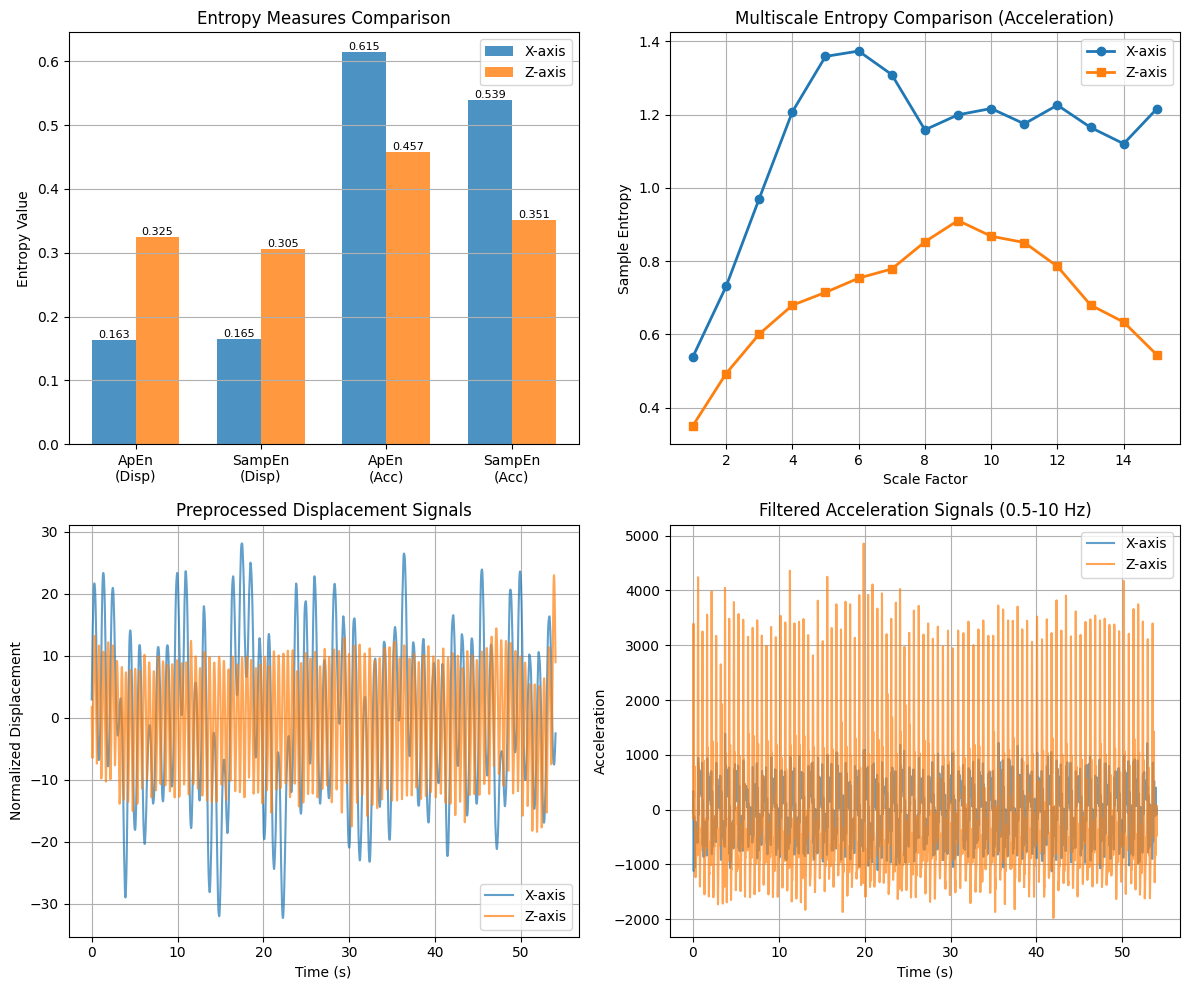


=== SUMMARY ===
Analysis duration: 54.03 seconds
Number of samples: 5403
Number of strides: 50

Entropy Results:

X-axis:
  Displacement - ApEn: 0.1625, SampEn: 0.1646
  Acceleration - ApEn: 0.6145, SampEn: 0.5394
  MSE (first 5): [0.53936083 0.73091079 0.9707012  1.20751778 1.35876206]

Z-axis:
  Displacement - ApEn: 0.3250, SampEn: 0.3054
  Acceleration - ApEn: 0.4573, SampEn: 0.3513
  MSE (first 5): [0.35128593 0.4930519  0.60084695 0.67954623 0.71462605]


In [5]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"03"/"markers.nc"
events_path = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"03"/"events.csv"

# Load dataset
ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

fs = 100.0  # sampling frequency in Hz

# How many consecutive left-leg strides you want:
N_STRIDES = 50
SKIP_SAMPLES = 200
skip_time = SKIP_SAMPLES / fs

# Load events
df = pd.read_csv(events_path)

# Make sure we have the expected columns
required_cols = {'time', 'label', 'context', 'icon_id'}
if not required_cols.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_cols} in events.csv, but got {df.columns.tolist()}"
    )

# Filter for left foot strikes (not foot-off)
left_fs_df = df[
    (df["context"] == "Left") & 
    (df["label"] == "Foot Strike") & 
    (df["time"] >= skip_time)
].copy()

left_fs_df.sort_values(by="time", inplace=True)

if len(left_fs_df) < N_STRIDES:
    raise ValueError(
        f"Found only {len(left_fs_df)} left-leg foot strike events, but need {N_STRIDES}."
    )

first_n = left_fs_df.iloc[:N_STRIDES]

start_time = first_n["time"].iloc[0]
end_time = first_n["time"].iloc[-1]

print(f"Using the first {N_STRIDES} left-leg FOOT STRIKE events:")
print(f"  Start time (1st L_FS) = {start_time:.4f} s")
print(f"  End time ({N_STRIDES}th L_FS) = {end_time:.4f} s")

# Get COM data
com = ds["markers"].sel(channel="COM")

# Process each axis separately
results = {}
r_factor = 0.2  # tolerance factor

for axis in ("x", "z"):
    print(f"\n--- {axis}-axis ---")
    
    # Extract the full signal for this axis
    ts_full = com.sel(axis=axis).values.ravel()
    
    # Extract the segment for analysis
    start_idx = int(start_time * fs)
    end_idx = int(end_time * fs)
    ts_segment = ts_full[start_idx:end_idx]
    ts_segment = preprocess_signal(ts_segment, fs=fs, hp_cutoff=0.1, lp_cutoff=30.0)
    
    print(f"Signal segment: {len(ts_segment)} samples ({len(ts_segment)/fs:.2f} seconds)")
    
    # 1. Compute entropy on displacement signal
    print("\nEntropy on Displacement Signal:")
    apen_disp, sampen_disp = compute_entropy_on_displacement(ts_segment, fs=fs, r_factor=r_factor)
    print(f"  ApEn   (m=2, r={r_factor}σ) = {apen_disp:.4f}")
    print(f"  SampEn (m=2, r={r_factor}σ) = {sampen_disp:.4f}")
    
    # 2. Compute entropy on acceleration signal
    print("\nEntropy on Acceleration Signal:")
    apen_acc, sampen_acc = compute_entropy_on_acceleration(ts_segment, fs=fs, r_factor=r_factor)
    print(f"  ApEn   (m=2, r={r_factor}σ) = {apen_acc:.4f}")
    print(f"  SampEn (m=2, r={r_factor}σ) = {sampen_acc:.4f}")
    
    # 3. Compute multiscale entropy on acceleration
    print("\nMultiscale Entropy on Acceleration:")
    scales, mse = compute_MSE_on_acceleration(ts_segment, r_factor=r_factor, fs=fs, max_scale=15)
    print(f"  Scales 1-5: {mse[:5]}")
    
    # Store results
    results[axis] = {
        'apen_disp': apen_disp,
        'sampen_disp': sampen_disp,
        'apen_acc': apen_acc,
        'sampen_acc': sampen_acc,
        'mse_scales': scales,
        'mse_values': mse
    }

# Create visualization comparing both axes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Entropy comparison bar chart
ax1 = axes[0, 0]
x_pos = np.arange(4)
width = 0.35

x_values = [results['x']['apen_disp'], results['x']['sampen_disp'], 
            results['x']['apen_acc'], results['x']['sampen_acc']]
z_values = [results['z']['apen_disp'], results['z']['sampen_disp'], 
            results['z']['apen_acc'], results['z']['sampen_acc']]

bars1 = ax1.bar(x_pos - width/2, x_values, width, label='X-axis', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, z_values, width, label='Z-axis', alpha=0.8)

ax1.set_ylabel('Entropy Value')
ax1.set_title('Entropy Measures Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['ApEn\n(Disp)', 'SampEn\n(Disp)', 'ApEn\n(Acc)', 'SampEn\n(Acc)'])
ax1.legend()
ax1.grid(True, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isinf(height) and not np.isnan(height):
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: MSE comparison
ax2 = axes[0, 1]
ax2.plot(results['x']['mse_scales'], results['x']['mse_values'], 'o-', label='X-axis', linewidth=2)
ax2.plot(results['z']['mse_scales'], results['z']['mse_values'], 's-', label='Z-axis', linewidth=2)
ax2.set_xlabel('Scale Factor')
ax2.set_ylabel('Sample Entropy')
ax2.set_title('Multiscale Entropy Comparison (Acceleration)')
ax2.legend()
ax2.grid(True)

# Plot 3: Displacement signals
ax3 = axes[1, 0]
t = np.arange(len(ts_segment)) / fs
ts_x = com.sel(axis='x').values.ravel()[start_idx:end_idx]
ts_z = com.sel(axis='z').values.ravel()[start_idx:end_idx]

# Preprocess for visualization
ts_x_prep = preprocess_signal(ts_x, fs=fs, hp_cutoff=0.1, lp_cutoff=30.0)
ts_z_prep = preprocess_signal(ts_z, fs=fs, hp_cutoff=0.1, lp_cutoff=30.0)

ax3.plot(t, ts_x_prep, label='X-axis', alpha=0.7)
ax3.plot(t, ts_z_prep, label='Z-axis', alpha=0.7)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Normalized Displacement')
ax3.set_title('Preprocessed Displacement Signals')
ax3.legend()
ax3.grid(True)

# Plot 4: Acceleration signals
ax4 = axes[1, 1]
# Compute accelerations
vel_x = np.gradient(ts_x, 1/fs)
acc_x = np.gradient(vel_x, 1/fs)
vel_z = np.gradient(ts_z, 1/fs)
acc_z = np.gradient(vel_z, 1/fs)

# Filter accelerations
acc_x_filt = _butter_filter(acc_x, fs, hp_cutoff=0.5, lp_cutoff=30.0)
acc_z_filt = _butter_filter(acc_z, fs, hp_cutoff=0.5, lp_cutoff=30.0)

ax4.plot(t, acc_x_filt, label='X-axis', alpha=0.7)
ax4.plot(t, acc_z_filt, label='Z-axis', alpha=0.7)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Acceleration')
ax4.set_title('Filtered Acceleration Signals (0.5-10 Hz)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== SUMMARY ===")
print(f"Analysis duration: {end_time - start_time:.2f} seconds")
print(f"Number of samples: {len(ts_segment)}")
print(f"Number of strides: {N_STRIDES}")

print("\nEntropy Results:")
for axis in ['x', 'z']:
    print(f"\n{axis.upper()}-axis:")
    print(f"  Displacement - ApEn: {results[axis]['apen_disp']:.4f}, SampEn: {results[axis]['sampen_disp']:.4f}")
    print(f"  Acceleration - ApEn: {results[axis]['apen_acc']:.4f}, SampEn: {results[axis]['sampen_acc']:.4f}")
    print(f"  MSE (first 5): {results[axis]['mse_values'][:5]}")